### Give Me Some Credit
Banks play a crucial role in market economies. They decide who can get finance and on what terms and can make or break investment decisions. For markets and society to function, individuals and companies need access to credit. 

The purpose of this report is to build a model with historical default data that both lenders and borrowers can use to help make the optimal financial decisions. The following steps were performed for training data preprocessing, model development, evaluation, and test data prediction:  

1. Exploratory Data Analysis (EDA)
2. Missing values analysis and treatment
3. Outliers detection and treatment
4. Target-feature correlation analysis
5. Feature-feature correlation analysis
6. Logistic Regression with 5-fold Cross Validation(cv)
7. Threshold analysis
8. Coefficients and odds ratio
9. Random Forest Modeling with 5-fold cv
10. XGBoost Modeling with 5-fold cv
11. Hyperparameter Tuning and Selection
12. Model performance evaluation: ROC-AUC, PR-AUC, KS statistic
13. Proability Calibration
14. Model Prediction on Test Set
15. Model Comparison and Conclusion

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict, train_test_split
from sklearn.metrics import (
    make_scorer,
    recall_score,
    precision_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    brier_score_loss,
    average_precision_score
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

In [3]:
# Load the datasets
train = pd.read_csv('cs-training.csv')
test = pd.read_csv('cs-test.csv')

In [4]:
train.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [5]:
print('training data shape:',train.shape)
print('test data shape:',test.shape)

training data shape: (150000, 12)
test data shape: (101503, 12)


In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

In [7]:
# Check target distribution
train['SeriousDlqin2yrs'].value_counts(normalize=True)


SeriousDlqin2yrs
0    0.93316
1    0.06684
Name: proportion, dtype: float64

6.68% of indiviuals experienced a 90-day-or-more past-due delinquency in the training dataset.

#### Missing Values

In [10]:
# check for missing values for training and test datasets
missing = train.isnull().sum()
print('trainging data:', missing[missing > 0])
missing_test = test.isnull().sum()
print('test data:', missing_test[missing_test > 0])

trainging data: MonthlyIncome         29731
NumberOfDependents     3924
dtype: int64
test data: SeriousDlqin2yrs      101503
MonthlyIncome          20103
NumberOfDependents      2626
dtype: int64


In [11]:
# Summary statistics by target variable BEFORE imputation
summary_before_imputation = (
    train.groupby('SeriousDlqin2yrs')[['MonthlyIncome', 'NumberOfDependents']]
    .agg(['mean', 'median', 'count'])
)

print("Mean and median values by target variable BEFORE imputation:")
display(summary_before_imputation)

Mean and median values by target variable BEFORE imputation:


MonthlyIncome                 NumberOfDependents         \
                          mean  median   count               mean median   
SeriousDlqin2yrs                                                           
0                  6747.837774  5466.0  111912           0.743417    0.0   
1                  5630.826493  4500.0    8357           0.948208    0.0   

                          
                   count  
SeriousDlqin2yrs          
0                 136229  
1                   9847

In [12]:
# Create missing-value indicators BEFORE imputation
for col in ['MonthlyIncome', 'NumberOfDependents']:
    train[f'{col}_missing'] = train[col].isna().astype(int)
    test[f'{col}_missing'] = test[col].isna().astype(int)

# Missing data vs. target variable (EDA only; no target leakage)
missing_vs_target = train.groupby('SeriousDlqin2yrs')[
    ['MonthlyIncome_missing', 'NumberOfDependents_missing']
].mean()

print('Missing-value rate by target group:')
display(missing_vs_target)

Missing-value rate by target group:


,MonthlyIncome_missing,NumberOfDependents_missing
SeriousDlqin2yrs,,
0,0.200480,0.026755
1,0.166467,0.017854


Based on the display above, we cannot conclude that missing information leads to default.

The MonthlyIncome has approximately 20% missing data, NumberOfDependents has 2.62%. Insteading of dropping entire rows which would result in the loss of a large amount of valuable information, missing value imputation would be applied. Even though defaulters tended to have lower average and median incomes compared with non-defaulters, we used the overall median calculated from the training set rather than target-based group medians, in order to avoid target leakage. We also created missing-value indicators to preserve the information associated with missingness. The same training-set median would be applied to the test set.


In [14]:
# Impute using medians calculated from the training set only
for col in ['MonthlyIncome', 'NumberOfDependents']:
    median_value = train[col].median()
    train[col] = train[col].fillna(median_value)
    test[col] = test[col].fillna(median_value)

#### Outliers

In [16]:
# Define numeric columns
numeric_cols = train.select_dtypes(include=['number']).columns.tolist()

# Describe with 99th percentile
train[numeric_cols].describe(percentiles=[0.25, 0.5, 0.75, 0.99]).T

,count,mean,std,min,25%,50%,75%,99%,max
Unnamed: 0,150000.0,75000.500000,43301.414527,1.0,37500.750000,75000.500000,112500.250000,148500.010000,150000.0
SeriousDlqin2yrs,150000.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.000000,1.0
RevolvingUtilizationOfUnsecuredLines,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,1.092956,50708.0
age,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,87.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,4.000000,98.0
DebtRatio,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,4979.040000,329664.0
MonthlyIncome,150000.0,6418.454920,12890.395542,0.0,3903.000000,5400.000000,7400.000000,23000.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,24.000000,58.0
NumberOfTimes90DaysLate,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,3.000000,98.0
NumberRealEstateLoansOrLines,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,4.000000,54.0


Based on the 99th percentile and max values of each variable, we observe that there are Potential Extreme Values in the training set.

In [18]:
# Proportion of DebtRatio>2
percent_above_2 = (train['DebtRatio'] >2).mean() * 100
print("DebtRatio > 2 percentage:", percent_above_2, "%")

DebtRatio > 2 percentage: 20.696666666666665 %


In [19]:
# Relationship between MonthlyIncome missing and DebtRatio > 2
pd.crosstab(train['MonthlyIncome_missing'], train['DebtRatio'] > 2)

DebtRatio,False,True
MonthlyIncome_missing,,
0,116968,3301
1,1987,27744


For the DebtRatio, mean >> median and a large gap between the 99th percnetile and max indicate the presence of high-end outliers that pull the mean upward. 
The 75th percentile is relatively low (<1) while the max is greater than 300k, which suggests that most individuals have relatively normal DebtRatio values, while only a small proportion have extremely high values.

There is 20.7% of the observations have a DebtRatio greater than 2. Among these observations, 27,744 out of 31,045 (approximately 89.4%) are associated with missing MonthlyIncome values. 

To reduce the influence of extreme DebtRatio values on the model, DebtRatio would be capped(clipped) at 2.

Similar variables that also contain extreme values include: MonthlyIncome, RevolvingUtilizationOfUnsecuredLines, NumberOfTimes90DaysLate, NumberOfTime30-59DaysPastDueNotWorse, NumberOfTime60-89DaysPastDueNotWorse, NumberOfDependents. Look at the following boxplots.

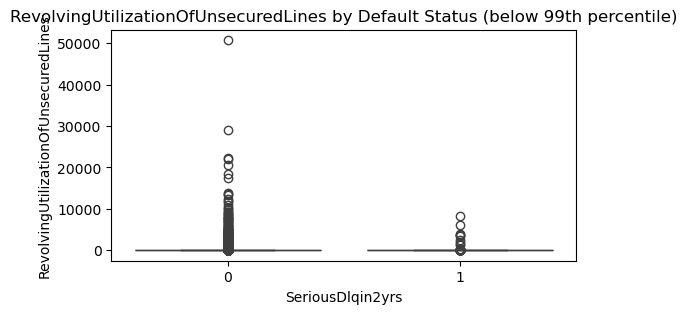

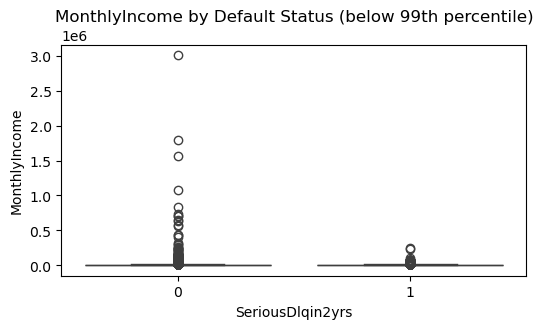

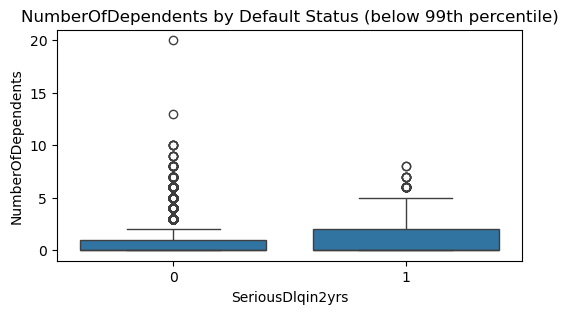

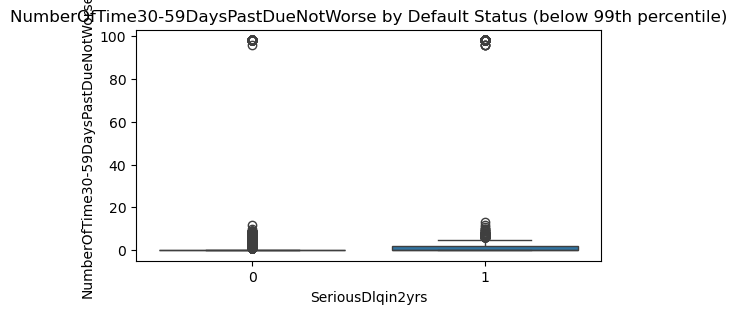

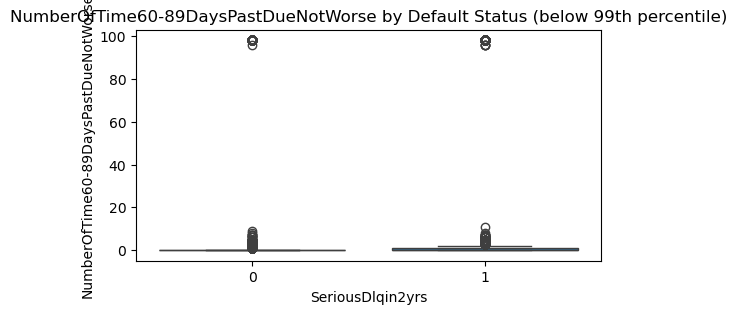

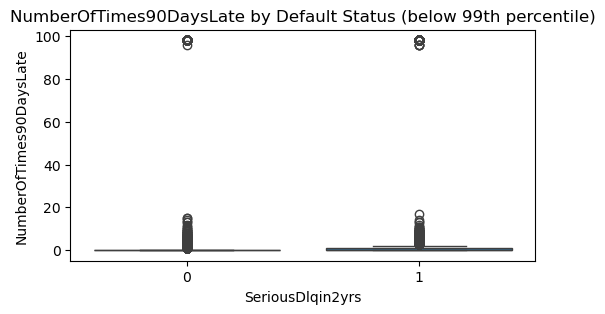

In [21]:
# Check for outliers in numeric columns using boxplots
features_to_compare = [
    'RevolvingUtilizationOfUnsecuredLines',
    'MonthlyIncome',
    'NumberOfDependents',
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]

for col in features_to_compare:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x='SeriousDlqin2yrs', y=col, data=train)
    
    plt.title(f'{col} by Default Status (below 99th percentile)')
    plt.xlabel('SeriousDlqin2yrs')
    plt.ylabel(col)
    plt.show()

For outliers, DebtRatio will be consistently clipped at 2 in both the training and test sets. clipping may remove some information contained in extreme DebtRatio values. For other features, the 99th-percentile upper bound will be determined from the training set and applied to both datasets to avoid data leakage.

In [23]:
# Clip DebtRatio at 2 for both training and test sets
# The same fixed threshold is applied to both datasets.
train['DebtRatio'] = train['DebtRatio'].clip(upper=2)
test['DebtRatio'] = test['DebtRatio'].clip(upper=2)


# Determine the upper bounds using only the training set
# to avoid data leakage.
outlier_cols = [
    'MonthlyIncome',
    'NumberOfTimes90DaysLate',
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'RevolvingUtilizationOfUnsecuredLines',
    'NumberOfDependents'
]

upper_limits = train[outlier_cols].quantile(0.99)

# Apply the training-set-derived upper limits to both
# training and test sets.
for col in outlier_cols:
    train[col] = train[col].clip(upper=upper_limits[col])
    test[col] = test[col].clip(upper=upper_limits[col])

#### Target-Feature Correlation 

Correlation with target variable:
SeriousDlqin2yrs                        1.000000
NumberOfTimes90DaysLate                 0.348427
NumberOfTime60-89DaysPastDueNotWorse    0.287964
NumberOfTime30-59DaysPastDueNotWorse    0.287911
RevolvingUtilizationOfUnsecuredLines    0.280813
NumberOfDependents                      0.047324
Unnamed: 0                              0.002801
DebtRatio                               0.002515
NumberRealEstateLoansOrLines           -0.007038
NumberOfDependents_missing             -0.013928
MonthlyIncome_missing                  -0.021308
NumberOfOpenCreditLinesAndLoans        -0.029669
MonthlyIncome                          -0.049790
age                                    -0.115386
Name: SeriousDlqin2yrs, dtype: float64


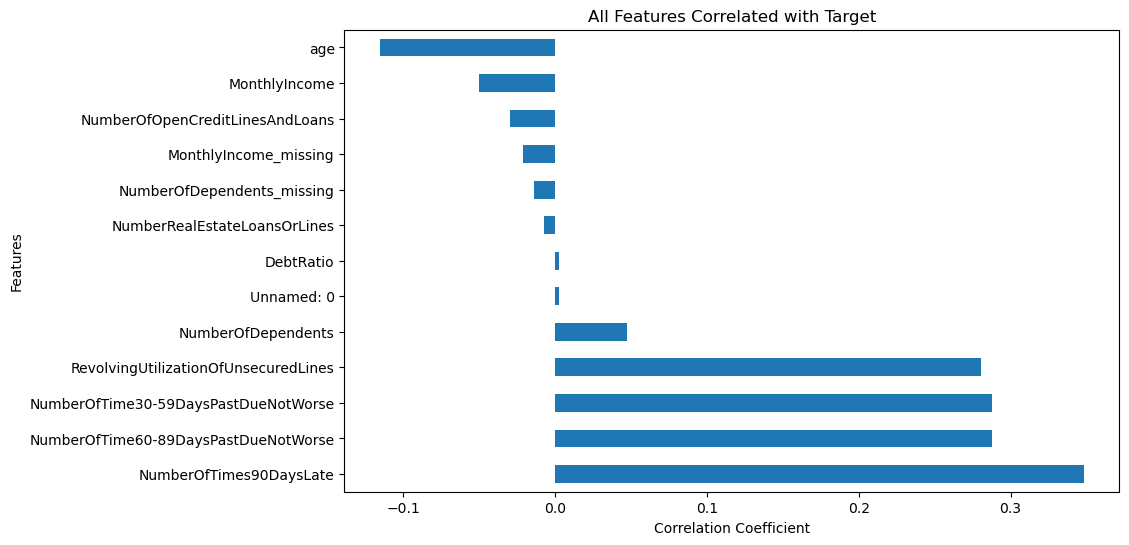

In [25]:
# View correlation with target variable (sorted)
target_corr = train.corr()['SeriousDlqin2yrs'].sort_values(ascending=False)
print("Correlation with target variable:")
print(target_corr)

# Visualize top 10 features with strongest correlation
plt.figure(figsize=(10, 6))
target_corr[1:].plot(kind='barh')
plt.title('All Features Correlated with Target')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.show()

#### Default vs. MontlyIncome

In [27]:
# Verify MonthlyIncome statistics by default status
print("MonthlyIncome statistics by default status:")
print(train.groupby('SeriousDlqin2yrs')['MonthlyIncome'].describe())

# Calculate median income difference percentage
median_default = train[train['SeriousDlqin2yrs'] == 1]['MonthlyIncome'].median()
median_non_default = train[train['SeriousDlqin2yrs'] == 0]['MonthlyIncome'].median()
diff_pct = ((median_non_default - median_default) / median_default) * 100
print(f"\nMedian MonthlyIncome difference: {diff_pct:.2f}%")

# Default rate for high income earners
high_income_default_rate = train[train['MonthlyIncome'] > 22000]['SeriousDlqin2yrs'].mean()
print(f"Default rate for MonthlyIncome > 22000: {high_income_default_rate*100:.2f}%")

# Default rate for low income earners
low_income_default_rate = train[train['MonthlyIncome'] < 3300]['SeriousDlqin2yrs'].mean()
print(f"Default rate for MonthlyIncome < 3300: {low_income_default_rate*100:.2f}%")

MonthlyIncome statistics by default status:
                     count         mean          std  min     25%     50%  \
SeriousDlqin2yrs                                                            
0                 139974.0  6193.556853  3853.657406  0.0  4000.0  5400.0   
1                  10026.0  5428.871933  3498.279422  0.0  3200.0  5240.0   

                     75%      max  
SeriousDlqin2yrs                   
0                 7500.0  23000.0  
1                 6200.0  23000.0  

Median MonthlyIncome difference: 3.05%
Default rate for MonthlyIncome > 22000: 5.16%
Default rate for MonthlyIncome < 3300: 9.20%


Defaulters have a lower median monthly income than non-defaulters. The median income of non-defaulters is approximately 3.05% higher than that of defaulters.

Customers with a monthly income below \\$3,300 have a higher default rate (9.20%) than customers with income above \\$22,000 (5.16%). This suggests that lower income is associated with increased default risk.

Note: The MonthlyIncome was previously capped at the 99th percentile.

Default vs. DebtRatio

In [30]:
train['DebtRatio_bin'] = pd.cut(
    train['DebtRatio'],
    bins=[-np.inf, 0.1, 0.3, 0.5, 1, 2],
    labels=['<=0.1', '0.1-0.3', '0.3-0.5', '0.5-1', '1-2']
)

debt_ratio_default_rate = train.groupby(
    'DebtRatio_bin',
    observed=False
)['SeriousDlqin2yrs'].agg(['count', 'mean'])

debt_ratio_default_rate['mean'] = (
    debt_ratio_default_rate['mean'] * 100
)

debt_ratio_default_rate.rename(
    columns={'mean': 'default_rate_percent'}
)

,count,default_rate_percent
DebtRatio_bin,,
<=0.1,24520,5.929853
0.1-0.3,38041,5.835809
0.3-0.5,31147,6.360163
0.5-1,21155,9.832191
1-2,35137,6.520192


DebtRatio has almost no marginal linear association with the target, although grouped analysis suggests a nonlinear and non-monotonic relationship, particularly for borrowers with DebtRatio between 0.5 and 1. Therefore, its low Pearson correlation should not be interpreted as evidence of limited predictive relevance; instead, the observed pattern suggests that nonlinear modelling approaches, such as tree-based models, may be useful for capturing its relationship with default risk. Note: the DebtRatio was previously capped at 2.

Default vs. Age

In [33]:
# Analyze age versus default status
print('Age statistics by default status:')
display(
    train.groupby('SeriousDlqin2yrs')['age']
    .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
)

age_corr = train[['age', 'SeriousDlqin2yrs']].corr().loc[
    'age', 'SeriousDlqin2yrs'
]
print(f'Correlation between age and default: {age_corr:.4f}')

# Compare default rates across age groups
age_bins = [0, 25, 35, 45, 55, 65, 75, np.inf]
age_labels = ['<=25', '26-35', '36-45', '46-55', '56-65', '66-75', '>75']
train['age_group'] = pd.cut(
    train['age'],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

age_default_rate = train.groupby(
    'age_group',
    observed=False
)['SeriousDlqin2yrs'].agg(['count', 'mean'])
age_default_rate['default_rate_percent'] = age_default_rate['mean'] * 100
print('\nDefault rate by age group:')
display(age_default_rate.drop(columns='mean'))

Age statistics by default status:


,count,mean,median,std,min,max
SeriousDlqin2yrs,,,,,,
0,139974,52.751375,52.0,14.791079,0,109
1,10026,45.926591,45.0,12.916289,21,101


Correlation between age and default: -0.1154

Default rate by age group:


,count,default_rate_percent
age_group,,
<=25,3028,11.162483
26-35,18458,11.122548
36-45,29819,8.813173
46-55,36690,7.593350
56-65,33406,4.583009
66-75,18470,2.615051
>75,10129,2.043637


Younger customers have a substantially higher default risk than older customers. The default rate is approximately five times higher for customers aged 35 or below than for customers older than 75. This suggests that age is an important risk factor, although the correlation is moderate and age should be combined with other financial variables in the predictive model.

In [35]:
# Count invalid age values
print('Training rows with age == 0:', (train['age'] == 0).sum())
print('Test rows with age == 0:', (test['age'] == 0).sum())

Training rows with age == 0: 1
Test rows with age == 0: 0


We observe that the min of age is 0, which is an invalid value. After confirming that there was only one such invalid observation, we decided to replace it with the median Age caculated from the training set.

In [37]:
# Replace invalid ages with the training-set median
train = train.drop(columns=['age_invalid'], errors='ignore')
train.loc[train['age'] <= 0, 'age'] = np.nan
age_median = train['age'].median()
train['age'] = train['age'].fillna(age_median)

Default vs. NumberOfTimes90DaysLate

In [39]:
# Analyze NumberOfTimes90DaysLate versus default status
late_corr = train[['NumberOfTimes90DaysLate', 'SeriousDlqin2yrs']].corr().loc[
    'NumberOfTimes90DaysLate', 'SeriousDlqin2yrs'
]
print(f'Correlation between 90-day late payments and default: {late_corr:.4f}')

late_default_rate = train.groupby(
    'NumberOfTimes90DaysLate'
)['SeriousDlqin2yrs'].agg(['count', 'mean'])
late_default_rate['default_rate_percent'] = late_default_rate['mean'] * 100

print('Default rate by number of 90-day late payments:')
display(late_default_rate.drop(columns='mean'))


Correlation between 90-day late payments and default: 0.3484
Default rate by number of 90-day late payments:


,count,default_rate_percent
NumberOfTimes90DaysLate,,
0,141662,4.626505
1,5243,33.663933
2,1555,49.903537
3,1540,60.454545


Default rates increase substantially as the number of 90-day-or-more past-due events rises. This indicates that 90-day delinquency history is a strong indicator of credit risk. Even a single 90-day-or-more late payment is associated with a substantial increase in the observed default rate. From a bank's perspective, borrowers with repeated serious delinquencies should therefore be considered high-risk customers and may warrant enhanced monitoring, more conservative credit limits, or additional risk controls.  
The particularly large jump from 4.63% to 33.66% after the first serious delinquency suggests that the occurrence of a 90-day delinquency itself may be an important early-warning signal for future default.  
However, this is an association rather than proof of causation. Banks should combine delinquency history with other risk indicators, when assessing a borrower's overall credit risk.  
Note: because the feature was clipped at the 99th percentile, the value 3 may represent three or more 90-day late payments.

Default vs. RevolvingUtilizationOfUnsecuredLines

In [42]:
# Analyze RevolvingUtilizationOfUnsecuredLines versus default status
utilization_corr = train[
    ['RevolvingUtilizationOfUnsecuredLines', 'SeriousDlqin2yrs']
].corr().loc['RevolvingUtilizationOfUnsecuredLines', 'SeriousDlqin2yrs']
print(f'Correlation between utilization and default: {utilization_corr:.4f}')

utilization_bins = [-np.inf, 0.1, 0.3, 0.5, 1, 2]
utilization_labels = ['<=0.1', '0.1-0.3', '0.3-0.5', '0.5-1', '1-2']
train['utilization_group'] = pd.cut(
    train['RevolvingUtilizationOfUnsecuredLines'],
    bins=utilization_bins,
    labels=utilization_labels
)

utilization_default_rate = train.groupby(
    'utilization_group', observed=False
)['SeriousDlqin2yrs'].agg(['count', 'mean'])
utilization_default_rate['default_rate_percent'] = (
    utilization_default_rate['mean'] * 100
)

print('Default rate by revolving utilization group:')
display(utilization_default_rate.drop(columns='mean'))

Correlation between utilization and default: 0.2808
Default rate by revolving utilization group:


,count,default_rate_percent
utilization_group,,
<=0.1,64404,1.810447
0.1-0.3,28478,3.142777
0.3-0.5,15830,5.849653
0.5-1,37967,15.281692
1-2,3321,37.247817


The results show a clear positive relationship between credit utilization and default risk. The correlation between utilization and default is 0.2808, indicating a moderate positive association. From a banking risk-management perspective, the increase in default rates is particularly significant once utilization exceeds 50%. Borrowers with utilization between 50% and 100% have a default rate of 15.28%, compared with only 1.81% for borrowers with utilization below 10%. The risk becomes even more pronounced for borrowers with utilization above 100%, whose default rate reaches 37.25%.   
This suggests that high revolving credit utilization can serve as an important risk indicator. Banks could use utilization levels as part of credit scoring and early-warning systems. Borrowers with rapidly increasing or persistently high utilization may warrant closer monitoring, lower additional credit exposure, or proactive risk-management measures.  
However, correlation does not imply causation. Credit utilization should therefore be considered together with other factors.  
Note: the variable was previously capped at the 99th percentile of the training set, compressing extreme values into the 1–2 range. The chart reflects the distribution after outlier treatment.

Default vs. NumberOfOpenCreditLinesAndLoans

In [45]:
# Analyze grouped NumberOfOpenCreditLinesAndLoans versus default status
credit_lines_corr = train[
    ['NumberOfOpenCreditLinesAndLoans', 'SeriousDlqin2yrs']
].corr().loc['NumberOfOpenCreditLinesAndLoans', 'SeriousDlqin2yrs']
print(f'Correlation between open credit lines and default: {credit_lines_corr:.4f}')

credit_lines_bins = [-np.inf, 0, 2, 5, 10, 20, np.inf]
credit_lines_labels = ['0', '1-2', '3-5', '6-10', '11-20', '>20']
train['credit_lines_group'] = pd.cut(
    train['NumberOfOpenCreditLinesAndLoans'],
    bins=credit_lines_bins,
    labels=credit_lines_labels
)

credit_lines_default_rate = train.groupby(
    'credit_lines_group', observed=False
)['SeriousDlqin2yrs'].agg(['count', 'mean'])
credit_lines_default_rate['default_rate_percent'] = (
    credit_lines_default_rate['mean'] * 100
)

print('Default rate by grouped number of open credit lines and loans:')
display(credit_lines_default_rate.drop(columns='mean'))


Correlation between open credit lines and default: -0.0297
Default rate by grouped number of open credit lines and loans:


,count,default_rate_percent
credit_lines_group,,
0,1888,25.635593
1-2,11104,10.752882
3-5,33598,6.678969
6-10,60400,5.538079
11-20,39030,6.354087
>20,3980,7.010050


The correlation is very close to zero, indicating that the number of open credit lines and loans has only a weak linear relationship with default risk.  
However, the grouped default rates reveal a more nuanced pattern: Default rates are highest among borrowers with no open credit lines and decline substantially before increasing slightly at higher credit counts. From a banking risk-management perspective,   
0 open credit lines: Default rate is 25.64%, which is exceptionally high. This may indicate borrowers with little or no established credit activity and therefore limited observable credit history. Banks should treat this group cautiously, although the small sample size (1,888) should also be considered.   
1–2 open accounts: The default rate falls to 10.75%, indicating lower but still relatively elevated risk.  
3–10 open accounts: Default rates decline to around 5.5%–6.7%, suggesting that borrowers with a moderate number of active credit accounts tend to have lower observed default risk.  
More than 10 accounts: Default risk increases slightly , reaching 7.01% for borrowers with more than 20 accounts. This may indicate that having a very large number of open accounts does not necessarily imply lower risk and could reflect greater credit exposure.  
Therefore, banks should not interpret a higher number of credit lines as automatically indicating higher or lower risk. Instead, this variable may be more useful as a measure of credit history and credit exposure when combined with other indicators.

#### Default vs. NumberOfDependents

In [48]:
# Analyze NumberOfDependents versus default status
dependents_corr = train[
    ['NumberOfDependents', 'SeriousDlqin2yrs']
].corr().loc['NumberOfDependents', 'SeriousDlqin2yrs']
print(f'Correlation between number of dependents and default: {dependents_corr:.4f}')

dependents_bins = [-np.inf, 0, 2, 4]
dependents_labels = ['0', '1-2', '3-4']
train['dependents_group'] = pd.cut(
    train['NumberOfDependents'],
    bins=dependents_bins,
    labels=dependents_labels
)

dependents_default_rate = train.groupby(
    'dependents_group', observed=False
)['SeriousDlqin2yrs'].agg(['count', 'mean'])
dependents_default_rate['default_rate_percent'] = (
    dependents_default_rate['mean'] * 100
)

print('Default rate by number of dependents:')
display(dependents_default_rate.drop(columns='mean'))

Correlation between number of dependents and default: 0.0473
Default rate by number of dependents:


,count,default_rate_percent
dependents_group,,
0,90826,5.806707
1-2,45838,7.677037
3-4,13336,9.245651


The correlation indicates a very weak positive linear relationship with default risk. Borrowers with more dependents tend to have higher observed default risk. One possible explanation is that a larger number of dependents may increase household financial obligations and reduce the borrower's disposable income available for debt repayment. As a result, these borrowers may have less financial flexibility to absorb unexpected expenses or income shocks.  
Note: The NumberOfDependents was previously capped at the 99th percentile, reducing the maximum value to 4.

#### Feature-Feature Correlation

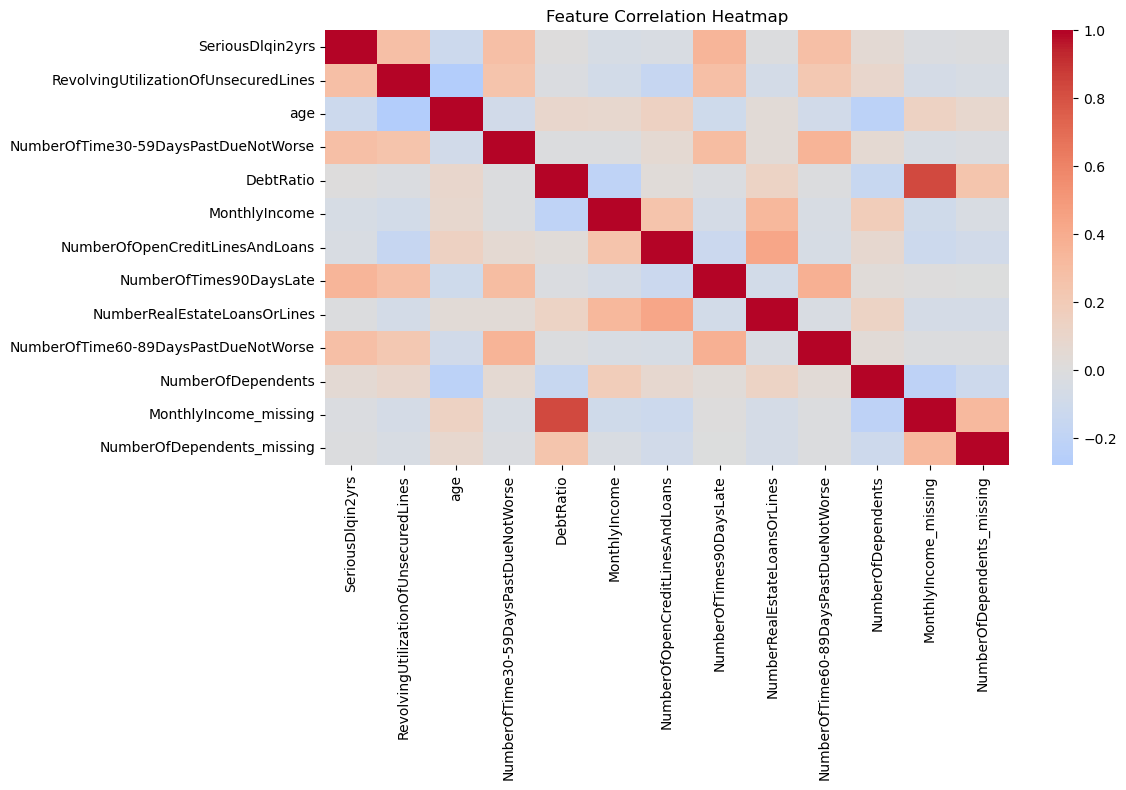

In [51]:
# Correlation heatmap for numeric features only
numeric_data = train.select_dtypes(include='number').drop(
    columns=['Unnamed: 0'],
    errors='ignore'
)

plt.figure(figsize=(12, 8))
sns.heatmap(
    numeric_data.corr(),
    cmap='coolwarm',
    center=0
)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

#### NumberOfTimes90DaysLate vs. RevolvingUtilizationOfUnsecuredLines

In [53]:
pd.crosstab(
    train['NumberOfTimes90DaysLate'] > 0,
    train['RevolvingUtilizationOfUnsecuredLines'] > 0.5,
    normalize='index'
)

RevolvingUtilizationOfUnsecuredLines,False,True
NumberOfTimes90DaysLate,,
False,0.752460,0.247540
True,0.253898,0.746102


The table examines the relationship between 90-day-or-more delinquency and high revolving credit utilization (>50%). Among borrowers who have experienced at least one 90-day-or-more delinquency, 74.61% also have revolving credit utilization above 50%. In contrast, only 24.75% of borrowers without a 90-day delinquency have utilization above 50%. This suggests that serious delinquency and high credit utilization frequently occur together, potentially indicating greater financial stress and difficulty managing debt obligations.

#### MonthlyIncome vs. DebtRatio

In [56]:
# Analyze MonthlyIncome missingness versus the original DebtRatio > 2 flag
# Reload the raw training data because train['DebtRatio'] was clipped earlier.
raw_train = pd.read_csv('cs-training.csv')
raw_train['MonthlyIncome_missing'] = raw_train['MonthlyIncome'].isna()
raw_train['DebtRatio_above_2'] = raw_train['DebtRatio'] > 2

counts = pd.crosstab(
    raw_train['MonthlyIncome_missing'],
    raw_train['DebtRatio_above_2']
)

row_percent = pd.crosstab(
    raw_train['MonthlyIncome_missing'],
    raw_train['DebtRatio_above_2'],
    normalize='index'
) * 100

column_percent = pd.crosstab(
    raw_train['MonthlyIncome_missing'],
    raw_train['DebtRatio_above_2'],
    normalize='columns'
) * 100

print('Row percentages:')
display(row_percent.round(2))
print('Column percentages:')
display(column_percent.round(2))

print(
    f"Among records with missing MonthlyIncome, "
    f"{row_percent.loc[True, True]:.2f}% have DebtRatio > 2."
)
print(
    f"Among records with DebtRatio > 2, "
    f"{column_percent.loc[True, True]:.2f}% have missing MonthlyIncome."
)

Row percentages:


DebtRatio_above_2,False,True
MonthlyIncome_missing,,
False,97.26,2.74
True,6.68,93.32


Column percentages:


DebtRatio_above_2,False,True
MonthlyIncome_missing,,
False,98.33,10.63
True,1.67,89.37


Among records with missing MonthlyIncome, 93.32% have DebtRatio > 2.
Among records with DebtRatio > 2, 89.37% have missing MonthlyIncome.


In [57]:
# Analyze MonthlyIncome versus DebtRatio using the raw training data
income_debt = raw_train[['MonthlyIncome', 'DebtRatio']].copy()
income_debt['MonthlyIncome_missing'] = income_debt['MonthlyIncome'].isna()
income_debt['DebtRatio_above_2'] = income_debt['DebtRatio'] > 2

# Analyze the numerical relationship among observations with reported income.
reported_income = income_debt[income_debt['MonthlyIncome'].notna()].copy()
reported_income_corr = reported_income[
    ['MonthlyIncome', 'DebtRatio']
].corr().loc['MonthlyIncome', 'DebtRatio']

print(
    f'Correlation between MonthlyIncome and DebtRatio '
    f'when income is reported: {reported_income_corr:.4f}'
)

income_bins = [-np.inf, 3300, 10000, 22000, np.inf]
income_labels = ['<=3,300', '3,301-10,000', '10,001-22,000', '>22,000']
income_debt['income_group'] = pd.cut(
    income_debt['MonthlyIncome'],
    bins=income_bins,
    labels=income_labels
)

income_debt_summary = income_debt.groupby(
    'income_group', observed=False
).agg(
    count=('DebtRatio', 'size'),
    median_debt_ratio=('DebtRatio', 'median'),
    mean_debt_ratio=('DebtRatio', 'mean'),
    extreme_debt_ratio_percent=('DebtRatio_above_2', 'mean')
)
income_debt_summary['extreme_debt_ratio_percent'] *= 100

print('DebtRatio by MonthlyIncome group:')
display(income_debt_summary.round(3))

missing_income = income_debt[income_debt['MonthlyIncome_missing']]
missing_income_summary = pd.DataFrame({
    'count': [len(missing_income)],
    'median_debt_ratio': [missing_income['DebtRatio'].median()],
    'extreme_debt_ratio_percent': [missing_income['DebtRatio_above_2'].mean() * 100]
}, index=['Income missing'])

print('Income-missing group:')
display(missing_income_summary.round(3))


Correlation between MonthlyIncome and DebtRatio when income is reported: -0.0287
DebtRatio by MonthlyIncome group:


,count,median_debt_ratio,mean_debt_ratio,extreme_debt_ratio_percent
income_group,,,,
"<=3,300",28674,0.346,110.492,10.766
"3,301-10,000",73276,0.302,0.349,0.242
"10,001-22,000",16671,0.257,0.291,0.210
">22,000",1648,0.147,0.190,0.121


Income-missing group:


,count,median_debt_ratio,extreme_debt_ratio_percent
Income missing,29731,1159.0,93.317


Among customers with reported income, MonthlyIncome and DebtRatio have almost no linear correlation. However, the median DebtRatio tends to decrease as income increases. The most important finding is that missing MonthlyIncome is strongly associated with extreme DebtRatio values: 93.32% of customers with missing income have a DebtRatio above 2. This suggests that extreme DebtRatio values are primarily related to missing or unreliable income information rather than normal income variation. From a banking risk-management perspective, missing income should therefore be treated not only as a data-quality issue but also as a potentially informative risk signal.

#### NumberOfTimes90DaysLate vs. NumberOfTime60-89DaysPastDueNotWorse vs. NumberOfTime30-59DaysPastDueNotWorse 

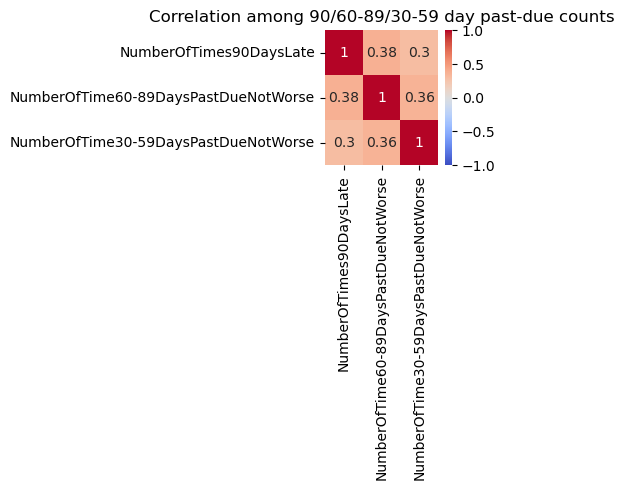

In [60]:
# Correlation analysis among the three delinquency features
features = [
    'NumberOfTimes90DaysLate',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTime30-59DaysPastDueNotWorse'
]
corr = train[features].corr()

# Visualize correlation matrix
plt.figure(figsize=(5, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation among 90/60-89/30-59 day past-due counts')
plt.tight_layout()
plt.show()

The Pearson correlation matrix indicates that the linear relationships among the three past-due features are weak to moderate, with coefficients ranging from 0.30 to 0.38. Given the absence of severe multicollinearity, all three indicators can be concurrently integrated into the regression framework to maximize the model's behavioral predictive power."

#### Preparation of Clean Data

In [63]:
# Missing values were handled during EDA; no imputation is used here.


model_data = train.select_dtypes(include='number').drop(
    columns=['SeriousDlqin2yrs', 'Unnamed: 0'],
    errors='ignore'
)

remaining_missing = model_data.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]
if not remaining_missing.empty:
    raise ValueError(
        f'EDA cleaning is incomplete: {remaining_missing.to_dict()}'
    )

X = model_data
y = train['SeriousDlqin2yrs']
feature_names = X.columns

#### Logistic Regression

In [65]:
# Prepare EDA-cleaned data for Logistic Regression
logistic_model = Pipeline([
    ('scaler', StandardScaler()),
    ('logistic', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])

print('Pipeline steps:', list(logistic_model.named_steps))

Pipeline steps: ['scaler', 'logistic']


#### 5-Fold Cross Validation (Same splits being used in all following models)

In [67]:
# Define the 5-fold stratified split and scoring metrics once, to be reused
# by Logistic Regression, threshold analysis, and Random Forest for a fair comparison


cv_5fold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    'roc_auc': 'roc_auc',
    'pr_auc': 'average_precision',
    'recall': make_scorer(recall_score),
    'precision': make_scorer(precision_score, zero_division=0)
}


In [68]:
# Simple Logistic Regression with 5-fold stratified cross-validation
cv_results = cross_validate(
    logistic_model,
    X,
    y,
    cv=cv_5fold,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

cv_summary = pd.DataFrame({
    'Metric': ['ROC-AUC', 'PR-AUC', 'Recall', 'Precision'],
    'Mean': [
        cv_results['test_roc_auc'].mean(),
        cv_results['test_pr_auc'].mean(),
        cv_results['test_recall'].mean(),
        cv_results['test_precision'].mean()
    ],
    'Std': [
        cv_results['test_roc_auc'].std(),
        cv_results['test_pr_auc'].std(),
        cv_results['test_recall'].std(),
        cv_results['test_precision'].std()
    ]
})

print('Simple Logistic Regression with 5-fold CV:')
display(cv_summary.round(4))

# Generate out-of-fold probabilities for threshold-based metrics.
oof_prob_5fold = cross_val_predict(
    logistic_model,
    X,
    y,
    cv=cv_5fold,
    method='predict_proba',
    n_jobs=-1
)[:, 1]

default_threshold = 0.5
oof_pred_5fold = (oof_prob_5fold >= default_threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y, oof_pred_5fold).ravel()
recall_05 = recall_score(y, oof_pred_5fold)
precision_05 = precision_score(y, oof_pred_5fold, zero_division=0)
f1_05 = f1_score(y, oof_pred_5fold, zero_division=0)
specificity_05 = tn / (tn + fp)
fpr_05 = fp / (tn + fp)

fpr_oof, tpr_oof, _ = roc_curve(y, oof_prob_5fold)
roc_auc_oof = roc_auc_score(y, oof_prob_5fold)
pr_auc_oof = average_precision_score(y, oof_prob_5fold)
ks_oof = np.max(tpr_oof - fpr_oof)

print('\n5-fold OOF metrics at threshold = 0.5:')
print(f'ROC-AUC: {roc_auc_oof:.4f}')
print(f'PR-AUC: {pr_auc_oof:.4f}')
print(f'KS statistic: {ks_oof:.4f}')
print(f'Recall: {recall_05:.4f}')
print(f'Precision: {precision_05:.4f}')
print(f'F1: {f1_05:.4f}')
print(f'Specificity: {specificity_05:.4f}')
print(f'False Positive Rate: {fpr_05:.4f}')

confusion_matrix_table = pd.DataFrame(
    [[tn, fp], [fn, tp]],
    index=['Actual 0', 'Actual 1'],
    columns=['Predicted 0', 'Predicted 1']
)
print('\nConfusion matrix:')
display(confusion_matrix_table)

print('Model evaluation complete. The confusion matrix and OOF metrics are shown above.')


Simple Logistic Regression with 5-fold CV:


,Metric,Mean,Std
0,ROC-AUC,0.8568,0.0045
1,PR-AUC,0.3803,0.0090
2,Recall,0.7435,0.0129
3,Precision,0.2180,0.0032



5-fold OOF metrics at threshold = 0.5:
ROC-AUC: 0.8567
PR-AUC: 0.3799
KS statistic: 0.5534
Recall: 0.7435
Precision: 0.2180
F1: 0.3372
Specificity: 0.8090
False Positive Rate: 0.1910

Confusion matrix:


,Predicted 0,Predicted 1
Actual 0,113239,26735
Actual 1,2572,7454


Model evaluation complete. The confusion matrix and OOF metrics are shown above.


The model separates the two classes reasonably well (ROC-AUC = 0.8567; KS = 0.5534). At the default threshold of 0.5, it identifies 74.35% of actual defaulters, while 21.8% of flagged customers are actual defaulters.  
The confusion matrix shows the trade-off clearly: 7,454 true defaults are detected, but 2,572 defaults are missed, and 26,735 non-defaults are flagged as potential defaults. This is a reasonable operating balance for a screening model, but it also illustrates the cost of a moderate threshold: the model is conservative enough to avoid excessive false alarms, while still retaining a strong recall for likely defaulters.

#### Calibration for Logistic Regression Predicted Probabilities
Step 1. Generate oof predictions with 5-fold cv for all the training data: oof_prob_5fold.
Step 2. Split the oof predictions into two subsets, one for fitting a calibrator, the other for evaluation (show in Reliability Diagram).

In [71]:
# Split existing OOF predictions into calibration and evaluation subsets
log_cal_prob, log_eval_prob, y_log_cal, y_log_eval = train_test_split(
    oof_prob_5fold,
    y,
    test_size=0.50,
    stratify=y,
    random_state=42
)


# ============================================================
# Fit Platt scaling ONLY on calibration subset
# ============================================================

platt_logistic = LogisticRegression(
    solver='lbfgs',
    max_iter=1000
)

platt_logistic.fit(
    log_cal_prob.reshape(-1, 1),
    y_log_cal
)


# ============================================================
# Apply calibration ONLY to evaluation subset
# ============================================================

log_eval_prob_calibrated = platt_logistic.predict_proba(
    log_eval_prob.reshape(-1, 1)
)[:, 1]


# ============================================================
# Evaluate before vs after calibration
# ============================================================

brier_log_before = brier_score_loss(
    y_log_eval,
    log_eval_prob
)

brier_log_after = brier_score_loss(
    y_log_eval,
    log_eval_prob_calibrated
)

roc_log_before = roc_auc_score(
    y_log_eval,
    log_eval_prob
)

roc_log_after = roc_auc_score(
    y_log_eval,
    log_eval_prob_calibrated
)


print('Logistic Regression Calibration')
print('--------------------------------------------')
print(f'Brier before calibration: {brier_log_before:.6f}')
print(f'Brier after calibration:  {brier_log_after:.6f}')
print()
print(f'ROC-AUC before calibration: {roc_log_before:.6f}')
print(f'ROC-AUC after calibration:  {roc_log_after:.6f}')


Logistic Regression Calibration
--------------------------------------------
Brier before calibration: 0.143574
Brier after calibration:  0.049647

ROC-AUC before calibration: 0.858680
ROC-AUC after calibration:  0.858680


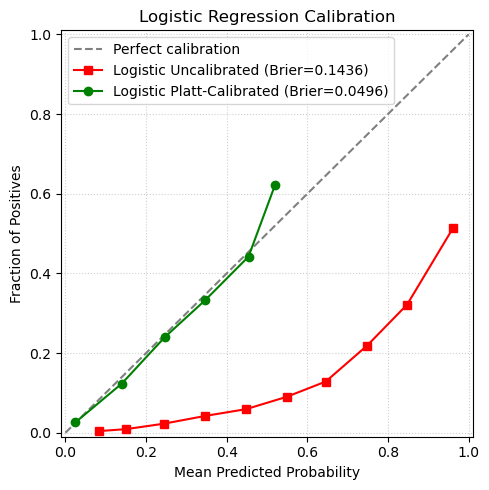

In [168]:
# ============================================================
# Reliability Diagram
# ============================================================

prob_true_log_before, prob_pred_log_before = calibration_curve(
    y_log_eval,
    log_eval_prob,
    n_bins=10,
    strategy='uniform'
)

prob_true_log_after, prob_pred_log_after = calibration_curve(
    y_log_eval,
    log_eval_prob_calibrated,
    n_bins=10,
    strategy='uniform'
)


plt.figure(figsize=(5, 5), dpi=100)

plt.plot(
    [0, 1],
    [0, 1],
    '--',
    color='gray',
    label='Perfect calibration'
)

plt.plot(
    prob_pred_log_before,
    prob_true_log_before,
    marker='s',
    color='red',
    label=f'Logistic Uncalibrated (Brier={brier_log_before:.4f})'
)

plt.plot(
    prob_pred_log_after,
    prob_true_log_after,
    marker='o',
    color='green',
    label=f'Logistic Platt-Calibrated (Brier={brier_log_after:.4f})'
)

plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Logistic Regression Calibration')

plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])

plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


#### Threshold Analysis

5-fold OOF ROC-AUC: 0.8567
5-fold OOF PR-AUC: 0.3799
5-fold OOF KS statistic: 0.5534

Per-fold threshold comparison (mean +/- std across the 5 folds):


,Threshold,Recall_Mean,Recall_Std,Precision_Mean,Precision_Std,F1_Mean,F1_Std,Specificity_Mean,FPR_Mean
0,0.4,0.8178,0.0097,0.1766,0.0019,0.2904,0.0030,0.7268,0.2732
1,0.5,0.7435,0.0144,0.2180,0.0036,0.3372,0.0054,0.8090,0.1910
2,0.6,0.6449,0.0169,0.2747,0.0048,0.3853,0.0067,0.8780,0.1220
3,0.7,0.5365,0.0107,0.3617,0.0069,0.4321,0.0072,0.9322,0.0678
4,0.8,0.4254,0.0136,0.4303,0.0131,0.4278,0.0124,0.9596,0.0404


Best threshold by F1: 0.7 (F1 = 0.4321)


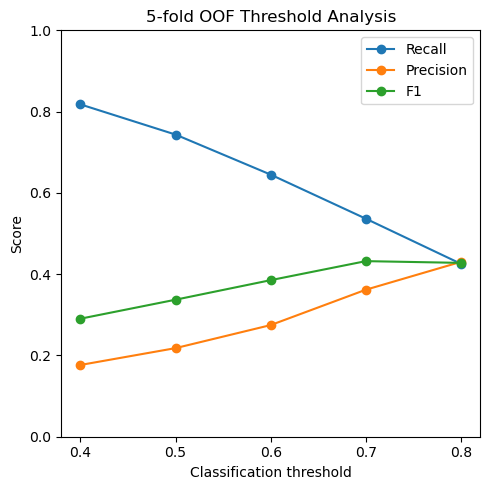

In [74]:
# Threshold analysis, computed per fold using the same cv_5fold splits


thresholds_to_compare = [0.4, 0.5, 0.6, 0.7, 0.8]

# These metrics do not depend on one fixed classification threshold.
fpr_oof, tpr_oof, _ = roc_curve(y, oof_prob_5fold)
roc_auc_oof = roc_auc_score(y, oof_prob_5fold)
pr_auc_oof = average_precision_score(y, oof_prob_5fold)
ks_oof = np.max(tpr_oof - fpr_oof)

print(f'5-fold OOF ROC-AUC: {roc_auc_oof:.4f}')
print(f'5-fold OOF PR-AUC: {pr_auc_oof:.4f}')
print(f'5-fold OOF KS statistic: {ks_oof:.4f}')

# Re-derive the same fold assignments used to build oof_prob_5fold, so each
# threshold is evaluated fold-by-fold instead of on the pooled OOF predictions.
threshold_fold_results = []
for fold_id, (_, test_idx) in enumerate(cv_5fold.split(X, y), start=1):
    fold_prob = oof_prob_5fold[test_idx]
    fold_y = y.iloc[test_idx]

    for threshold in thresholds_to_compare:
        fold_pred = (fold_prob >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(fold_y, fold_pred).ravel()

        threshold_fold_results.append({
            'Fold': fold_id,
            'Threshold': threshold,
            'Recall': recall_score(fold_y, fold_pred),
            'Precision': precision_score(fold_y, fold_pred, zero_division=0),
            'F1': f1_score(fold_y, fold_pred, zero_division=0),
            'Specificity': tn / (tn + fp),
            'False Positive Rate': fp / (tn + fp),
            'TP': tp,
            'FP': fp,
            'FN': fn,
            'TN': tn
        })

threshold_fold_results = pd.DataFrame(threshold_fold_results)

threshold_results_5fold = threshold_fold_results.groupby('Threshold').agg(
    Recall_Mean=('Recall', 'mean'),
    Recall_Std=('Recall', 'std'),
    Precision_Mean=('Precision', 'mean'),
    Precision_Std=('Precision', 'std'),
    F1_Mean=('F1', 'mean'),
    F1_Std=('F1', 'std'),
    Specificity_Mean=('Specificity', 'mean'),
    FPR_Mean=('False Positive Rate', 'mean')
).reset_index()

print('\nPer-fold threshold comparison (mean +/- std across the 5 folds):')
display(threshold_results_5fold.round(4))

best_threshold_row = threshold_results_5fold.loc[
    threshold_results_5fold['F1_Mean'].idxmax()
]
best_threshold = best_threshold_row['Threshold']
print(
    f"Best threshold by F1: {best_threshold:.1f} "
    f"(F1 = {best_threshold_row['F1_Mean']:.4f})"
)

plt.figure(figsize=(5, 5))
plt.plot(
    threshold_results_5fold['Threshold'],
    threshold_results_5fold['Recall_Mean'],
    marker='o',
    label='Recall'
)
plt.plot(
    threshold_results_5fold['Threshold'],
    threshold_results_5fold['Precision_Mean'],
    marker='o',
    label='Precision'
)
plt.plot(
    threshold_results_5fold['Threshold'],
    threshold_results_5fold['F1_Mean'],
    marker='o',
    label='F1'
)
plt.xlabel('Classification threshold')
plt.ylabel('Score')
plt.title('5-fold OOF Threshold Analysis')
plt.xticks(thresholds_to_compare)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

The threshold analysis shows a clear trade-off between capturing potential defaulters and avoiding unnecessary risk flags for non-defaulters. As the threshold increases, Recall decreases, while Precision and Specificity increase.  
Lowering the threshold to 0.4 increases recall to 81.78%, allowing the model to capture more potential defaulters, but results in a high false-positive rate of 27.32%. From a banking perspective, this is a risk-averse strategy because the bank prioritizes identifying potential defaulters.  
As the threshold increases, precision and specificity improve, while recall declines.  
At a threshold of 0.7, the model achieves the highest F1 score among the tested thresholds (0.4321), with a precision of 36.17% and a false-positive rate of only 6.78%. However, recall falls to 53.65%, meaning that a substantial proportion of actual defaulters would be missed.  
From a banking risk-management perspective, threshold selection should therefore reflect the bank's risk appetite and the relative costs of false negatives and false positives. A lower threshold may be preferable for a conservative credit-risk strategy focused on minimizing potential credit losses, whereas a higher threshold may be more appropriate when the bank places greater emphasis on reducing unnecessary restrictions on potentially profitable borrowers. F1-score can support the decision, but should not be used as the sole criterion for selecting the final threshold.

#### Coefficients and Odds Ratios

In [77]:
# Logistic Regression
# Fit the final model on all EDA-cleaned training data before reading coefficients.
logistic_model.fit(X, y)

coefficient_values = logistic_model.named_steps['logistic'].coef_[0]

coefficient_table = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficient_values,
    'Odds_Ratio': np.exp(coefficient_values),
    'Absolute_Coefficient': np.abs(coefficient_values)
}).sort_values(
    'Absolute_Coefficient',
    ascending=False
).drop(columns='Absolute_Coefficient')

print('All features ranked by absolute coefficient:')
display(coefficient_table.round(4))

All features ranked by absolute coefficient:


,Feature,Coefficient,Odds_Ratio
0,RevolvingUtilizationOfUnsecuredLines,0.7240,2.0627
6,NumberOfTimes90DaysLate,0.4346,1.5444
2,NumberOfTime30-59DaysPastDueNotWorse,0.3954,1.4850
8,NumberOfTime60-89DaysPastDueNotWorse,0.2882,1.3340
1,age,-0.2833,0.7533
5,NumberOfOpenCreditLinesAndLoans,0.1968,1.2175
4,MonthlyIncome,-0.1367,0.8722
7,NumberRealEstateLoansOrLines,0.1186,1.1259
10,MonthlyIncome_missing,-0.1129,0.8932
3,DebtRatio,0.0818,1.0852


The key variables associated with higher default risk are credit utilization and previous delinquency behavior. Revolving credit utilization has the largest positive association with default. A one-standard-deviation increase in RevolvingUtilizationOfUnsecuredLines is associated with approximately 2.06 times the odds of default, holding all other variables constant. In contrast, age and monthly income are negatively associated with default risk, suggesting that older borrowers and borrowers with higher income tend to have lower modeled default risk, conditional on other factors.  
From a banking risk-management perspective, the results support using delinquency history and revolving credit utilization as key indicators for credit-risk monitoring and early-warning systems. However, the coefficients should be interpreted as conditional associations rather than causal effects, and the magnitude of each odds ratio depends on the unit and scaling of the corresponding feature.

#### Prediction on Test Set Using Fitted Logistic Regression Model

In [80]:
# ============================================================
# Logistic Regression Test Predictions
# ============================================================

test_features = test.reindex(columns=feature_names)

missing_test_features = test_features.isnull().sum()
missing_test_features = missing_test_features[
    missing_test_features > 0
]

if not missing_test_features.empty:
    raise ValueError(
        f'Test set is missing required feature values: '
        f'{missing_test_features.to_dict()}'
    )


# Original Logistic probability
test_logistic_prob = logistic_model.predict_proba(
    test_features
)[:, 1]


# Platt-calibrated probability
test_logistic_prob_calibrated = platt_logistic.predict_proba(
    test_logistic_prob.reshape(-1, 1)
)[:, 1]


# Save both probabilities
test_predictions_logistic = pd.DataFrame({
    'Id': (
        test['Unnamed: 0']
        if 'Unnamed: 0' in test.columns
        else np.arange(1, len(test) + 1)
    ),
    'Default_Risk_Rate_Logistic': test_logistic_prob,
    'Default_Risk_Rate_Logistic_Calibrated':
        test_logistic_prob_calibrated
})


output_path = 'test_default_predictions_logistic_calibrated.xlsx'

test_predictions_logistic.to_excel(
    output_path,
    index=False
)

print(
    f'Saved {len(test_predictions_logistic)} '
    f'Logistic predictions to {output_path}'
)

display(test_predictions_logistic.head())


Saved 101503 Logistic predictions to test_default_predictions_logistic_calibrated.xlsx


,Id,Default_Risk_Rate_Logistic,Default_Risk_Rate_Logistic_Calibrated
0,1,0.501860,0.072165
1,2,0.423670,0.048566
2,3,0.185946,0.013988
3,4,0.487644,0.067203
4,5,0.652306,0.148862


#### Random Forest Hyperparameter Tuning
Basically, Random Forest uses bootstrap sampling, which naturally allows it to generate out-of-bag (OOB) predictions for the training data. However, for consistency and a fair comparison with XGBoost and logistic regression, we apply the same 5-fold cross-validation splits and use them to fit and generate out-of-fold predictions for the Random Forest as well.

In [82]:
# Random Forest with 5-fold CV, sweeping min_samples_leaf, using the same cv_5fold splits as Logistic Regression
min_samples_leaf_values = [60, 80, 100, 120]
rf_leaf_cv_summary = []

for min_samples_leaf in min_samples_leaf_values:
    rf_model = RandomForestClassifier(
        n_estimators=75,
        min_samples_leaf=min_samples_leaf,
        max_features='sqrt',
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )

    rf_cv_results = cross_validate(
        rf_model,
        X,
        y,
        cv=cv_5fold,
        scoring=scoring,
        return_train_score=False,
        n_jobs=1
    )

    rf_leaf_cv_summary.append({
        'min_samples_leaf': min_samples_leaf,
        'ROC-AUC_Mean': rf_cv_results['test_roc_auc'].mean(),
        'ROC-AUC_Std': rf_cv_results['test_roc_auc'].std(),
        'PR-AUC_Mean': rf_cv_results['test_pr_auc'].mean(),
        'PR-AUC_Std': rf_cv_results['test_pr_auc'].std(),
        'Recall_Mean': rf_cv_results['test_recall'].mean(),
        'Precision_Mean': rf_cv_results['test_precision'].mean()
    })

rf_leaf_cv_summary = pd.DataFrame(rf_leaf_cv_summary)

display(rf_leaf_cv_summary.round(4))

# Fit the final Random Forest model (best min_samples_leaf by ROC-AUC) on all training data
best_min_samples_leaf = rf_leaf_cv_summary.loc[
    rf_leaf_cv_summary['ROC-AUC_Mean'].idxmax(), 'min_samples_leaf'
]

,min_samples_leaf,ROC-AUC_Mean,ROC-AUC_Std,PR-AUC_Mean,PR-AUC_Std,Recall_Mean,Precision_Mean
0,60,0.8628,0.0035,0.3913,0.0086,0.7402,0.2337
1,80,0.8634,0.0036,0.3903,0.0086,0.7553,0.2271
2,100,0.8634,0.0035,0.3887,0.0084,0.7623,0.2230
3,120,0.8634,0.0036,0.3881,0.0080,0.7663,0.2191


In [83]:
print('The best min_samples_leaf = ', f'{best_min_samples_leaf}')
print('min_samples_leaf controls the minimum number of observations allowed in each terminal\
leaf of a decision tree. A larger value prevents the Random Forest from creating overly small\
customer segments, thereby reducing overfitting and improving generalization. In our 5-fold\
cross-validation, min_samples_leaf =produced the highest mean ROC-AUC among the tested values.')

The best min_samples_leaf =  80
min_samples_leaf controls the minimum number of observations allowed in each terminalleaf of a decision tree. A larger value prevents the Random Forest from creating overly smallcustomer segments, thereby reducing overfitting and improving generalization. In our 5-foldcross-validation, min_samples_leaf =produced the highest mean ROC-AUC among the tested values.


#### Fit Random Forest model to compute feature importance

In [85]:
# Fit Random Forest model with the best hyperparameter to compute feature importance

rf_model = RandomForestClassifier(
    n_estimators=150,
    min_samples_leaf=best_min_samples_leaf,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X, y)

rf_feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print('Feature importances:')
display(rf_feature_importance.round(4))


Feature importances:


,Feature,Importance
0,RevolvingUtilizationOfUnsecuredLines,0.3479
6,NumberOfTimes90DaysLate,0.1759
2,NumberOfTime30-59DaysPastDueNotWorse,0.1745
8,NumberOfTime60-89DaysPastDueNotWorse,0.0896
1,age,0.0628
3,DebtRatio,0.0434
4,MonthlyIncome,0.0379
5,NumberOfOpenCreditLinesAndLoans,0.0362
7,NumberRealEstateLoansOrLines,0.0198
9,NumberOfDependents,0.0088


The variables contributing most strongly to the Random Forest's predictive decisions are credit utilization and previous delinquency behavior. Revolving credit utilization is the most important feature, accounting for 34.79% of the total feature importance, followed by 30–59 day and 90-day delinquency measures. Collectively, credit utilization and delinquency-related variables account for approximately 78.79% of the total feature importance. This suggests that current credit usage and historical repayment behavior are substantially more informative for predicting default than demographic and financial variables such as age, income, and number of dependents.

#### Calibration for RF Predicted Probabilities
Step 1: Generate Random Forest 5-fold OOF probabilities using the same 5-fold splits as logistic regression.
Step 2: Fit Platt-scaling (sigmoid) on RF OOF probabilities to achieve calibrated probabilities.

In [88]:
# Generate out-of-fold predicted probabilities
rf_oof_prob = cross_val_predict(
    rf_model,
    X,
    y,
    cv=cv_5fold,
    method='predict_proba',
    n_jobs=-1
)[:, 1]

In [89]:
# --------------------------------------------------
# Split existing RF OOF predictions into
# calibration and evaluation subsets
# --------------------------------------------------

rf_cal_prob, rf_eval_prob, y_cal, y_eval = train_test_split(
    rf_oof_prob,
    y,
    test_size=0.50,
    stratify=y,
    random_state=42
)

# --------------------------------------------------
# Fit Platt scaling ONLY on calibration subset
# --------------------------------------------------

platt_rf = LogisticRegression(
    solver='lbfgs',
    max_iter=1000
)

platt_rf.fit(
    rf_cal_prob.reshape(-1, 1),
    y_cal
)

# --------------------------------------------------
# Evaluate Platt scaling ONLY on evaluation subset
# --------------------------------------------------

rf_eval_prob_calibrated = platt_rf.predict_proba(
    rf_eval_prob.reshape(-1, 1)
)[:, 1]

brier_rf_before = brier_score_loss(
    y_eval,
    rf_eval_prob
)

brier_rf_after = brier_score_loss(
    y_eval,
    rf_eval_prob_calibrated
)

roc_rf_before = roc_auc_score(
    y_eval,
    rf_eval_prob
)

roc_rf_after = roc_auc_score(
    y_eval,
    rf_eval_prob_calibrated
)

print(f'RF Evaluation Brier before calibration: {brier_rf_before:.6f}')
print(f'RF Evaluation Brier after calibration:  {brier_rf_after:.6f}')

print(f'RF Evaluation ROC-AUC before calibration: {roc_rf_before:.6f}')
print(f'RF Evaluation ROC-AUC after calibration:  {roc_rf_after:.6f}')


RF Evaluation Brier before calibration: 0.131082
RF Evaluation Brier after calibration:  0.049505
RF Evaluation ROC-AUC before calibration: 0.864918
RF Evaluation ROC-AUC after calibration:  0.864918


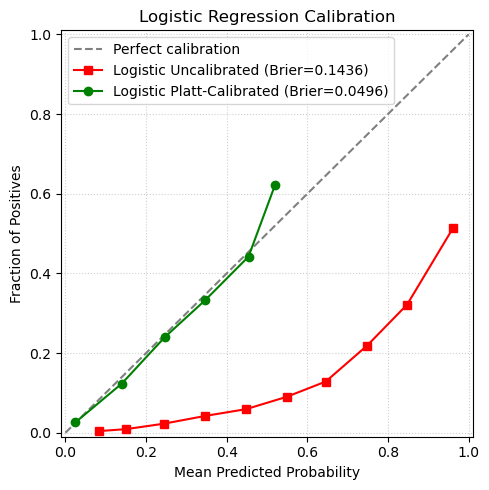

In [90]:
# ============================================================
# Reliability Diagram
# ============================================================

prob_true_log_before, prob_pred_log_before = calibration_curve(
    y_log_eval,
    log_eval_prob,
    n_bins=10,
    strategy='uniform'
)

prob_true_log_after, prob_pred_log_after = calibration_curve(
    y_log_eval,
    log_eval_prob_calibrated,
    n_bins=10,
    strategy='uniform'
)


plt.figure(figsize=(5, 5), dpi=100)

plt.plot(
    [0, 1],
    [0, 1],
    '--',
    color='gray',
    label='Perfect calibration'
)

plt.plot(
    prob_pred_log_before,
    prob_true_log_before,
    marker='s',
    color='red',
    label=f'Logistic Uncalibrated (Brier={brier_log_before:.4f})'
)

plt.plot(
    prob_pred_log_after,
    prob_true_log_after,
    marker='o',
    color='green',
    label=f'Logistic Platt-Calibrated (Brier={brier_log_after:.4f})'
)

plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Logistic Regression Calibration')

plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])

plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


The sigmoid-calibrated Random Forest showed improved probability calibration compared with the original Random Forest. The calibrated model produced probabilities that were closer to the observed default rates across risk groups, while maintaining similar discriminatory performance. This suggests that sigmoid calibration improves the reliability of the predicted probabilities and makes them more suitable for estimating probability of default (PD). The following cell shows that the RF model achieved an OOF ROC-AUC of 0.8636 both before and after sigmoid (Platt) calibration, indicating that calibration did not affect the model's discriminatory performance. 

In [92]:
# ============================================================
# Fit final Platt calibrator using ALL RF OOF predictions
# for final test-set probability calibration
# ============================================================

platt_rf_final = LogisticRegression(
    solver='lbfgs',
    max_iter=1000
)

platt_rf_final.fit(
    rf_oof_prob.reshape(-1, 1),
    y
)

LogisticRegression(max_iter=1000)

#### Prediction on Test Set with Random Forests and Calibration.

In [94]:
# Select the same features and order as training data
test_features = test.reindex(columns=feature_names)

# Exclude rows with missing required features
valid_test_mask = ~test_features.isnull().any(axis=1)

test_valid = test.loc[valid_test_mask].copy()
test_features_valid = test_features.loc[valid_test_mask].copy()

print(f'Total test observations: {len(test)}')
print(f'Valid observations: {len(test_valid)}')
print(f'Excluded due to missing values: {(~valid_test_mask).sum()}')

# Original RF probability
test_rf_prob = rf_model.predict_proba(
    test_features_valid
)[:, 1]

# Final Platt-calibrated probability
test_rf_prob_cal = platt_rf_final.predict_proba(
    test_rf_prob.reshape(-1, 1)
)[:, 1]

# Save predictions
test_predictions_rf = pd.DataFrame({
    'Id': (
        test_valid['Unnamed: 0']
        if 'Unnamed: 0' in test_valid.columns
        else np.arange(1, len(test_valid) + 1)
    ),
    'Default_Risk_Rate_RF': test_rf_prob,
    'Default_Risk_Rate_RF_Calibrated': test_rf_prob_cal
})

# Save to Excel
output_path = 'test_default_predictions_rf_calibrated.xlsx'

test_predictions_rf.to_excel(
    output_path,
    index=False
)

print(f'Saved {len(test_predictions_rf)} RF predictions to {output_path}')

display(test_predictions_rf.head())

Total test observations: 101503
Valid observations: 101503
Excluded due to missing values: 0
Saved 101503 RF predictions to test_default_predictions_rf_calibrated.xlsx


,Id,Default_Risk_Rate_RF,Default_Risk_Rate_RF_Calibrated
0,1,0.450563,0.060535
1,2,0.351958,0.035790
2,3,0.158255,0.012406
3,4,0.468563,0.066521
4,5,0.621813,0.143786


#### XGBoost Tree Number Tuning

In [96]:
n_estimators_values = [1500, 1600, 1700, 1800]

cv_scores = {
    n: {
        'roc_auc': [],
        'pr_auc': [],
        'ks': []
    }
    for n in n_estimators_values
}

for fold, (train_idx, val_idx) in enumerate(cv_5fold.split(X, y), 1):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]
    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    xgb_model = XGBClassifier(
        n_estimators=1800,
        max_depth=4,
        learning_rate=0.01,
        objective='binary:logistic',
        eval_metric='auc',
        random_state=42,
        n_jobs=-1
    )

    xgb_model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    # Get probability after different numbers of trees
    for n in n_estimators_values:

        val_prob = xgb_model.predict_proba(
            X_val,
            iteration_range=(0, n)
        )[:, 1]

        # ROC-AUC
        roc_auc = roc_auc_score(y_val, val_prob)

        # PR-AUC
        pr_auc = average_precision_score(y_val, val_prob)

        # KS statistic
        data = pd.DataFrame({
            'y': y_val.values,
            'prob': val_prob
        }).sort_values('prob', ascending=False)

        data['cum_event'] = (
            data['y'].cumsum() / data['y'].sum()
        )

        data['cum_non_event'] = (
            (1 - data['y']).cumsum() / (1 - data['y']).sum()
        )

        ks = np.max(
            np.abs(
                data['cum_event'] - data['cum_non_event']
            )
        )

        cv_scores[n]['roc_auc'].append(roc_auc)
        cv_scores[n]['pr_auc'].append(pr_auc)
        cv_scores[n]['ks'].append(ks)

    print(f"Finished fold {fold}/5")

Finished fold 1/5
Finished fold 2/5
Finished fold 3/5
Finished fold 4/5
Finished fold 5/5


In [97]:
xgb_cv_summary = pd.DataFrame({
    'n_estimators': n_estimators_values,

    'ROC-AUC_Mean': [
        np.mean(cv_scores[n]['roc_auc'])
        for n in n_estimators_values
    ],

    'ROC-AUC_Std': [
        np.std(cv_scores[n]['roc_auc'])
        for n in n_estimators_values
    ],

    'PR-AUC_Mean': [
        np.mean(cv_scores[n]['pr_auc'])
        for n in n_estimators_values
    ],

    'PR-AUC_Std': [
        np.std(cv_scores[n]['pr_auc'])
        for n in n_estimators_values
    ],

    'KS_Mean': [
        np.mean(cv_scores[n]['ks'])
        for n in n_estimators_values
    ],

    'KS_Std': [
        np.std(cv_scores[n]['ks'])
        for n in n_estimators_values
    ]
})

display(xgb_cv_summary.round(4))

,n_estimators,ROC-AUC_Mean,ROC-AUC_Std,PR-AUC_Mean,PR-AUC_Std,KS_Mean,KS_Std
0,1500,0.8653,0.0041,0.4010,0.0092,0.5775,0.0098
1,1600,0.8654,0.0041,0.4009,0.0091,0.5779,0.0101
2,1700,0.8653,0.0041,0.4007,0.0087,0.5779,0.0100
3,1800,0.8653,0.0041,0.4005,0.0087,0.5777,0.0101


In [98]:
# Compute out-of-fold probabilities using chosen n_estimators to inspect OOF ROC-AUC
best_n = 1600
xgb_final = XGBClassifier(
    n_estimators=best_n,
    max_depth=4,
    learning_rate=0.01,
    objective='binary:logistic',
    #use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
oof_prob_xgb = cross_val_predict(xgb_final, X, y, cv=cv_5fold, method='predict_proba', n_jobs=-1)[:, 1]

# ROC-AUC
roc_auc_xgb = roc_auc_score(y, oof_prob_xgb)

# PR-AUC
pr_auc_xgb = average_precision_score(y, oof_prob_xgb)

# KS statistic
ks_data = pd.DataFrame({
    'y': np.asarray(y),
    'prob': oof_prob_xgb
}).sort_values('prob', ascending=False)

ks_data['cum_event'] = (
    ks_data['y'].cumsum() / ks_data['y'].sum()
)

ks_data['cum_non_event'] = (
    (1 - ks_data['y']).cumsum()
    / (1 - ks_data['y']).sum()
)

ks_xgb = np.max(
    np.abs(
        ks_data['cum_event']
        - ks_data['cum_non_event']
    )
)

print(f'XGBoost OOF ROC-AUC: {roc_auc_xgb:.6f}')
print(f'XGBoost OOF PR-AUC:  {pr_auc_xgb:.6f}')
print(f'XGBoost OOF KS:      {ks_xgb:.6f}')


XGBoost OOF ROC-AUC: 0.865264
XGBoost OOF PR-AUC:  0.400469
XGBoost OOF KS:      0.576253


#### Calibration for XGBoost Predicted Probabilities

In [100]:
xgb_cal_prob, xgb_eval_prob, y_cal_xgb, y_eval_xgb = train_test_split(
    oof_prob_xgb,
    y,
    test_size=0.50,
    stratify=y,
    random_state=42
)

platt_xgb = LogisticRegression(
    solver='lbfgs',
    max_iter=1000
)

platt_xgb.fit(
    xgb_cal_prob.reshape(-1, 1),
    y_cal_xgb
)

xgb_eval_prob_calibrated = platt_xgb.predict_proba(
    xgb_eval_prob.reshape(-1, 1)
)[:, 1]

brier_xgb_before = brier_score_loss(
    y_eval_xgb,
    xgb_eval_prob
)

brier_xgb_after = brier_score_loss(
    y_eval_xgb,
    xgb_eval_prob_calibrated
)

roc_xgb_before = roc_auc_score(
    y_eval_xgb,
    xgb_eval_prob
)

roc_xgb_after = roc_auc_score(
    y_eval_xgb,
    xgb_eval_prob_calibrated
)

print(f'XGB Evaluation Brier before calibration: {brier_xgb_before:.6f}')
print(f'XGB Evaluation Brier after calibration:  {brier_xgb_after:.6f}')

print(f'XGB Evaluation ROC-AUC before calibration: {roc_xgb_before:.6f}')
print(f'XGB Evaluation ROC-AUC after calibration:  {roc_xgb_after:.6f}')


XGB Evaluation Brier before calibration: 0.048765
XGB Evaluation Brier after calibration:  0.050339
XGB Evaluation ROC-AUC before calibration: 0.866580
XGB Evaluation ROC-AUC after calibration:  0.866580


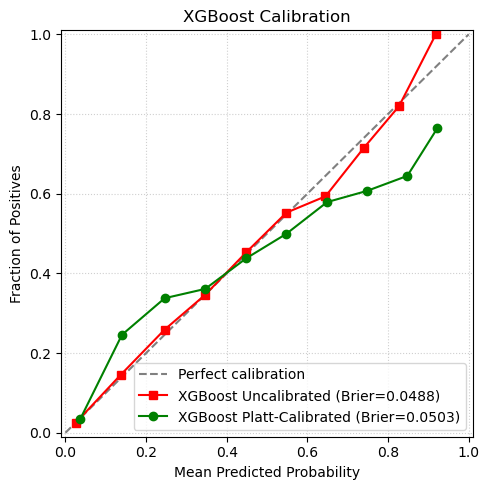

In [101]:
# ============================================================
# Reliability Diagram - XGBoost Method B
# Evaluation subset only
# ============================================================

prob_true_xgb_before, prob_pred_xgb_before = calibration_curve(
    y_eval_xgb,
    xgb_eval_prob,
    n_bins=10,
    strategy='uniform'
)

prob_true_xgb_after, prob_pred_xgb_after = calibration_curve(
    y_eval_xgb,
    xgb_eval_prob_calibrated,
    n_bins=10,
    strategy='uniform'
)


plt.figure(figsize=(5, 5), dpi=100)

# Perfect calibration line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    color='gray',
    label='Perfect calibration'
)

# Before calibration
plt.plot(
    prob_pred_xgb_before,
    prob_true_xgb_before,
    marker='s',
    color='red',
    label=f'XGBoost Uncalibrated (Brier={brier_xgb_before:.4f})'
)

# After Platt calibration
plt.plot(
    prob_pred_xgb_after,
    prob_true_xgb_after,
    marker='o',
    color='green',
    label=f'XGBoost Platt-Calibrated (Brier={brier_xgb_after:.4f})'
)


plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('XGBoost Calibration')

plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])

plt.grid(
    True,
    linestyle=':',
    alpha=0.6
)

plt.legend()
plt.tight_layout()
plt.show()


XGBoost did not benefit from Platt calibration.

#### Prediction on Test Set with XGBoost

In [104]:
# ============================================================
# Fit final Platt calibrator using ALL XGBoost OOF predictions
# This calibrator is used only for final test-set prediction
# ============================================================

platt_xgb_final = LogisticRegression(
    solver='lbfgs',
    max_iter=1000
)

platt_xgb_final.fit(
    oof_prob_xgb.reshape(-1, 1),
    y
)


LogisticRegression(max_iter=1000)

In [105]:
# ============================================================
# Fit final XGBoost on all training data
# ============================================================

xgb_final.fit(X, y)


# ============================================================
# Prepare test features
# ============================================================

test_features = test.reindex(columns=feature_names)

missing_test_features = test_features.isnull().sum()
missing_test_features = missing_test_features[
    missing_test_features > 0
]

if not missing_test_features.empty:
    raise ValueError(
        f'Test set is missing required feature values: '
        f'{missing_test_features.to_dict()}'
    )


# ============================================================
# Original XGBoost probability
# ============================================================

test_default_risk_xgb = xgb_final.predict_proba(
    test_features
)[:, 1]


# ============================================================
# Final Platt-calibrated XGBoost probability
# ============================================================

test_default_risk_xgb_calibrated = platt_xgb_final.predict_proba(
    test_default_risk_xgb.reshape(-1, 1)
)[:, 1]


# ============================================================
# Save both original and calibrated probabilities
# ============================================================

test_predictions_xgb = pd.DataFrame({
    'Id': (
        test['Unnamed: 0']
        if 'Unnamed: 0' in test.columns
        else pd.RangeIndex(
            start=1,
            stop=len(test) + 1
        )
    ),
    'Default_Risk_Rate_XGB': test_default_risk_xgb,
    'Default_Risk_Rate_XGB_Calibrated':
        test_default_risk_xgb_calibrated
})


output_path = 'test_default_predictions_xgb_calibrated.xlsx'

test_predictions_xgb.to_excel(
    output_path,
    index=False
)

print(
    f'Saved {len(test_predictions_xgb)} '
    f'XGBoost predictions to {output_path}'
)

display(test_predictions_xgb.head())


Saved 101503 XGBoost predictions to test_default_predictions_xgb_calibrated.xlsx


,Id,Default_Risk_Rate_XGB,Default_Risk_Rate_XGB_Calibrated
0,1,0.063540,0.043328
1,2,0.046132,0.038163
2,3,0.012595,0.029831
3,4,0.077993,0.048118
4,5,0.106109,0.058908


### Model Comparison and Conclusion

Three classification models were evaluated using the same stratified 5-fold cross-validation framework: Logistic Regression, Random Forest, and XGBoost. Model performance was assessed using ROC-AUC, PR-AUC, calibration performance, and probability-based evaluation.

The Logistic Regression model achieved an OOF ROC-AUC of approximately 0.8567 and a PR-AUC of approximately 0.3799. The model provides strong interpretability, making it attractive for credit-risk applications where transparency and coefficient-based explanations are important. However, its linear functional form may limit its ability to capture nonlinear relationships and interactions among borrower characteristics. In addition, because class balancing was used during model fitting, calibration of the resulting probabilities is particularly important before interpreting them as probability-of-default estimates.

The Random Forest model achieved a higher OOF ROC-AUC of approximately 0.8637. Feature importance analysis showed that revolving credit utilization and delinquency-related variables account for approximately 78.79% of total impurity-based feature importance. This suggests that borrower credit utilization and repayment history contain substantial predictive information. However, feature importance should be interpreted as predictive association rather than causal influence.

XGBoost produced the strongest overall discriminatory performance, with an OOF ROC-AUC of 0.8653, PR-AUC of 0.4005, and KS statistic of 0.5763. The advantage over Random Forest and Logistic Regression is relatively modest in ROC-AUC terms, but XGBoost achieved the highest PR-AUC among the three models. The result suggests that gradient-boosted trees capture nonlinear patterns in utilization, delinquency history, age, income, and other borrower characteristics particularly effectively.

Threshold analysis demonstrates that classification performance depends strongly on the selected operating point. For Logistic Regression, increasing the threshold from 0.4 to 0.7 reduced recall from 81.78% to 53.65% while improving precision from 17.66% to 36.17% and reducing the false-positive rate from 27.32% to 6.78%. Although 0.7 produced the highest F1 score among the tested thresholds, F1 should not be treated as the sole basis for selecting a banking decision threshold. The final threshold should instead reflect the relative economic costs of false negatives and false positives and the institution's risk appetite.

Probability calibration is also important because the intended application is credit-risk assessment rather than classification alone. Calibration results indicate that calibration methods can substantially improve the reliability of predicted probabilities, while preserving ranking performance. Therefore, the final model should be evaluated using both discrimination metrics and calibration metrics rather than ROC-AUC alone.

Overall, XGBoost is the preferred candidate model for predictive performance, based on its highest observed ROC-AUC, PR-AUC, and KS statistic. Random Forest provides a strong alternative with similar discriminatory performance, while Logistic Regression offers the greatest interpretability but slightly lower predictive performance.

However, the results should not be interpreted as evidence that XGBoost is automatically suitable for regulatory or production deployment. Before deployment in a real banking environment, additional validation would be required, including out-of-time testing, calibration and back-testing, population stability analysis, stress testing, model stability assessment, economic cost analysis, and appropriate model governance and regulatory review.

For the present study, the recommended approach is therefore to select XGBoost as the best-performing candidate model, while retaining Logistic Regression as an interpretable benchmark and Random Forest as a competitive alternative. The final classification threshold should be selected according to the relative business costs of false positives and false negatives rather than solely according to the maximum F1 score.